In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import itertools

from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from scipy.stats import chi2_contingency


from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [23]:
raw_df = pd.read_csv('../data/f3_data/f3_no_outliers.csv')
raw_df

features = [
    'mean_0',
    'std_0',
    'dwell_0',
    'mean_1',
    'std_1',
    'dwell_1',
    'mean_2',
    'std_2',
    'dwell_2'
]

# 1. Explore original features

## a. EDA

In [24]:
raw_df_p = raw_df.melt(
    id_vars='label',
    value_vars=features,
    var_name='feature',
    value_name='value'
)

raw_df_p

,label,feature,value
0,0,mean_0,0.007557
1,0,mean_0,0.005918
2,0,mean_0,0.007050
3,0,mean_0,0.009852
4,0,mean_0,0.009862
...,...,...,...
1096537,1,dwell_2,81.725352
1096538,0,dwell_2,80.156061
1096539,1,dwell_2,84.501667
1096540,0,dwell_2,82.289474


### Original PCA Plot

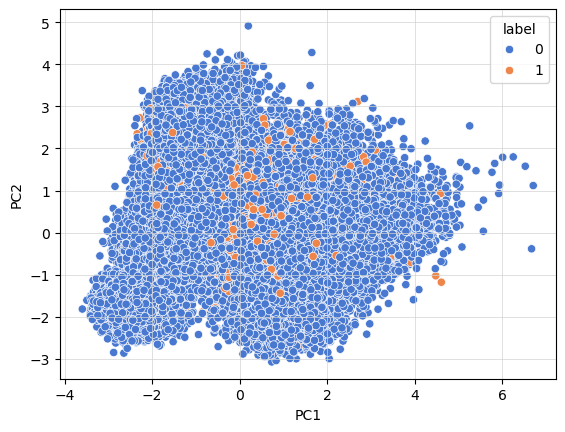

In [25]:
X = raw_df.drop(columns=['transcript_id', 'transcript_position', 'sequence', 'gene_id', 'label'])
y = raw_df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['label'] = y


sns.scatterplot(pca_df, x='PC1', y='PC2', hue='label', palette='muted')
plt.grid(color='lightgray', linewidth=0.5)
plt.show()

### Boxplots

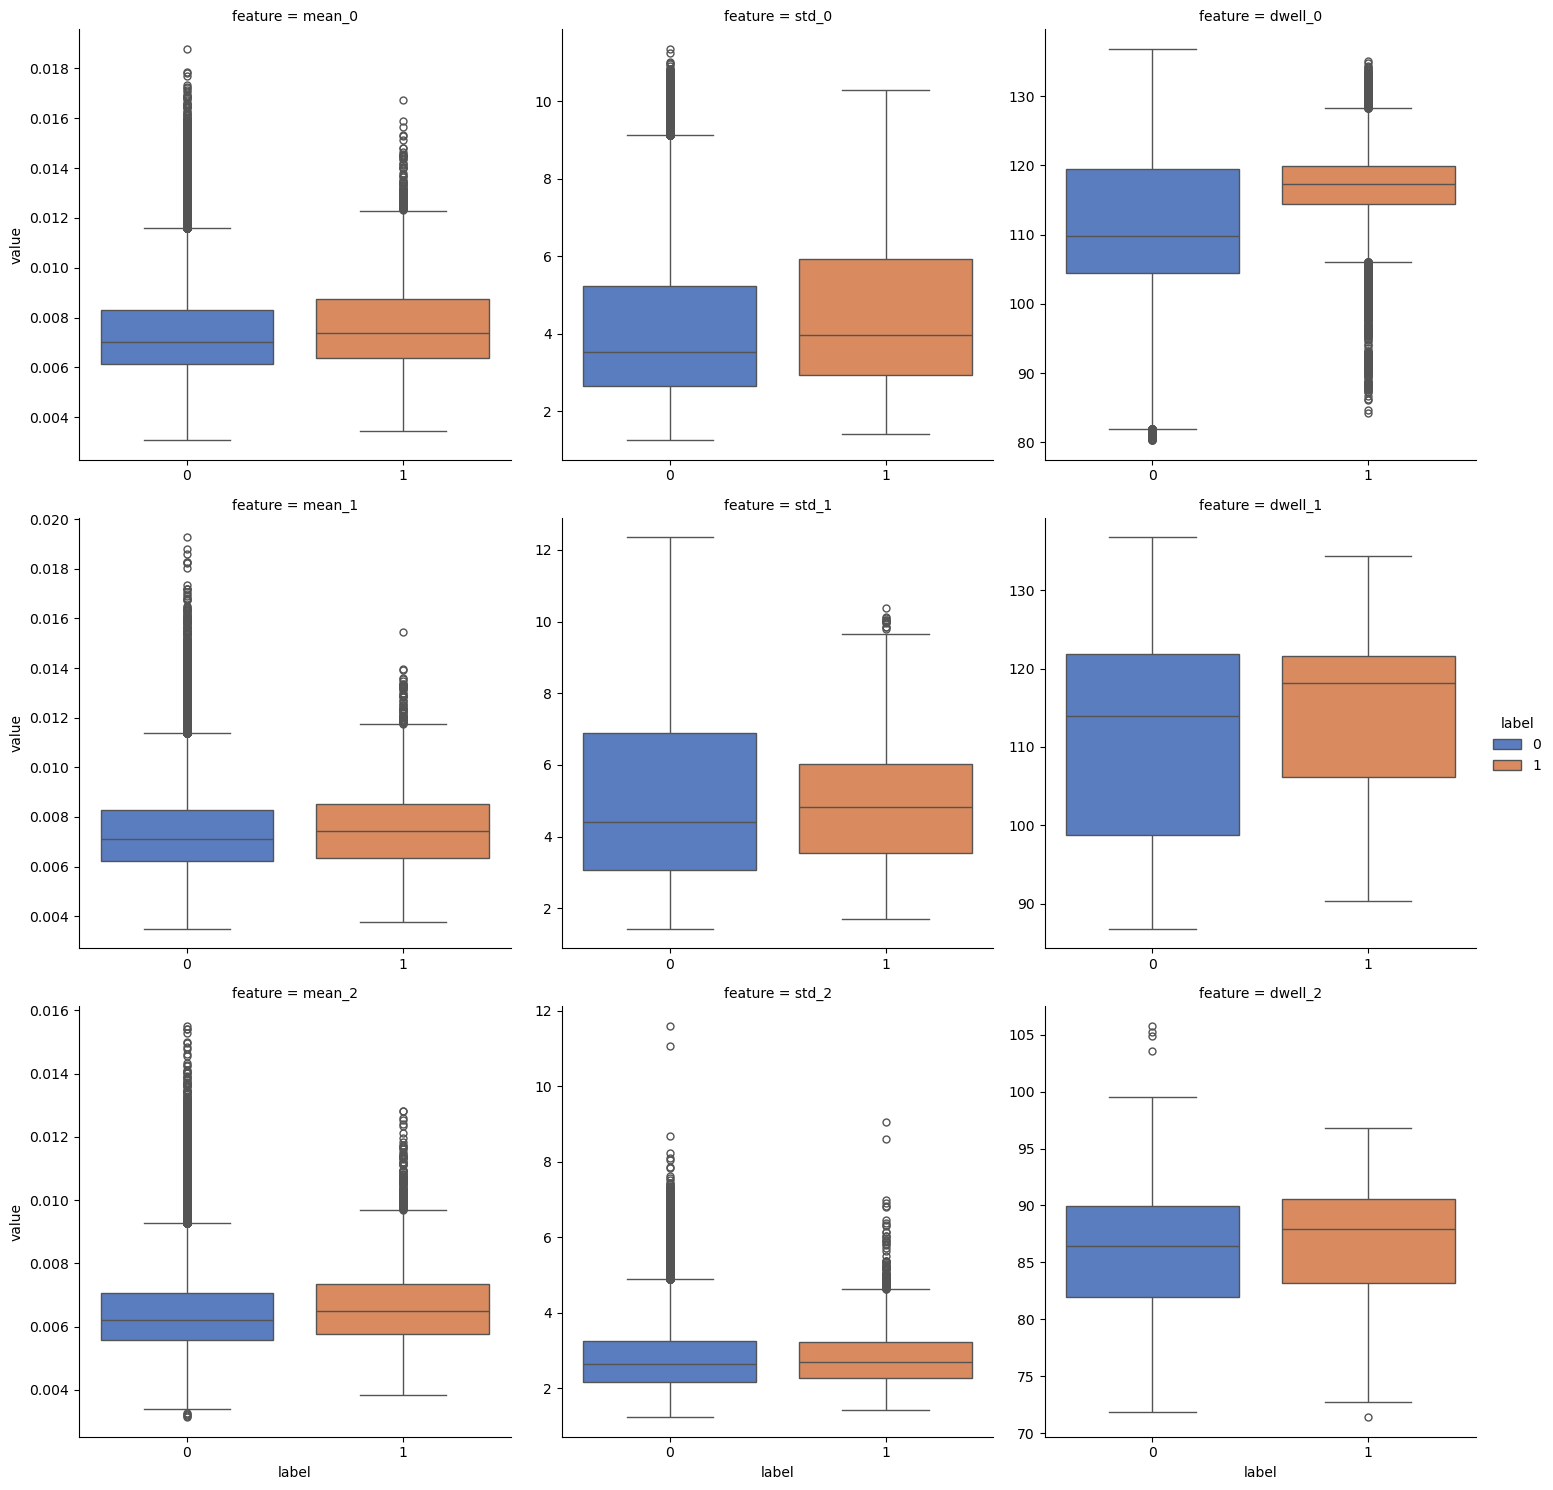

In [26]:
g = sns.catplot(
    data=raw_df_p,
    x='label',
    y='value',
    hue='label',
    col='feature',
    col_wrap=3,       
    kind='box',
    palette='muted',
    sharex=False, sharey=False
)


plt.show()

### Histograms

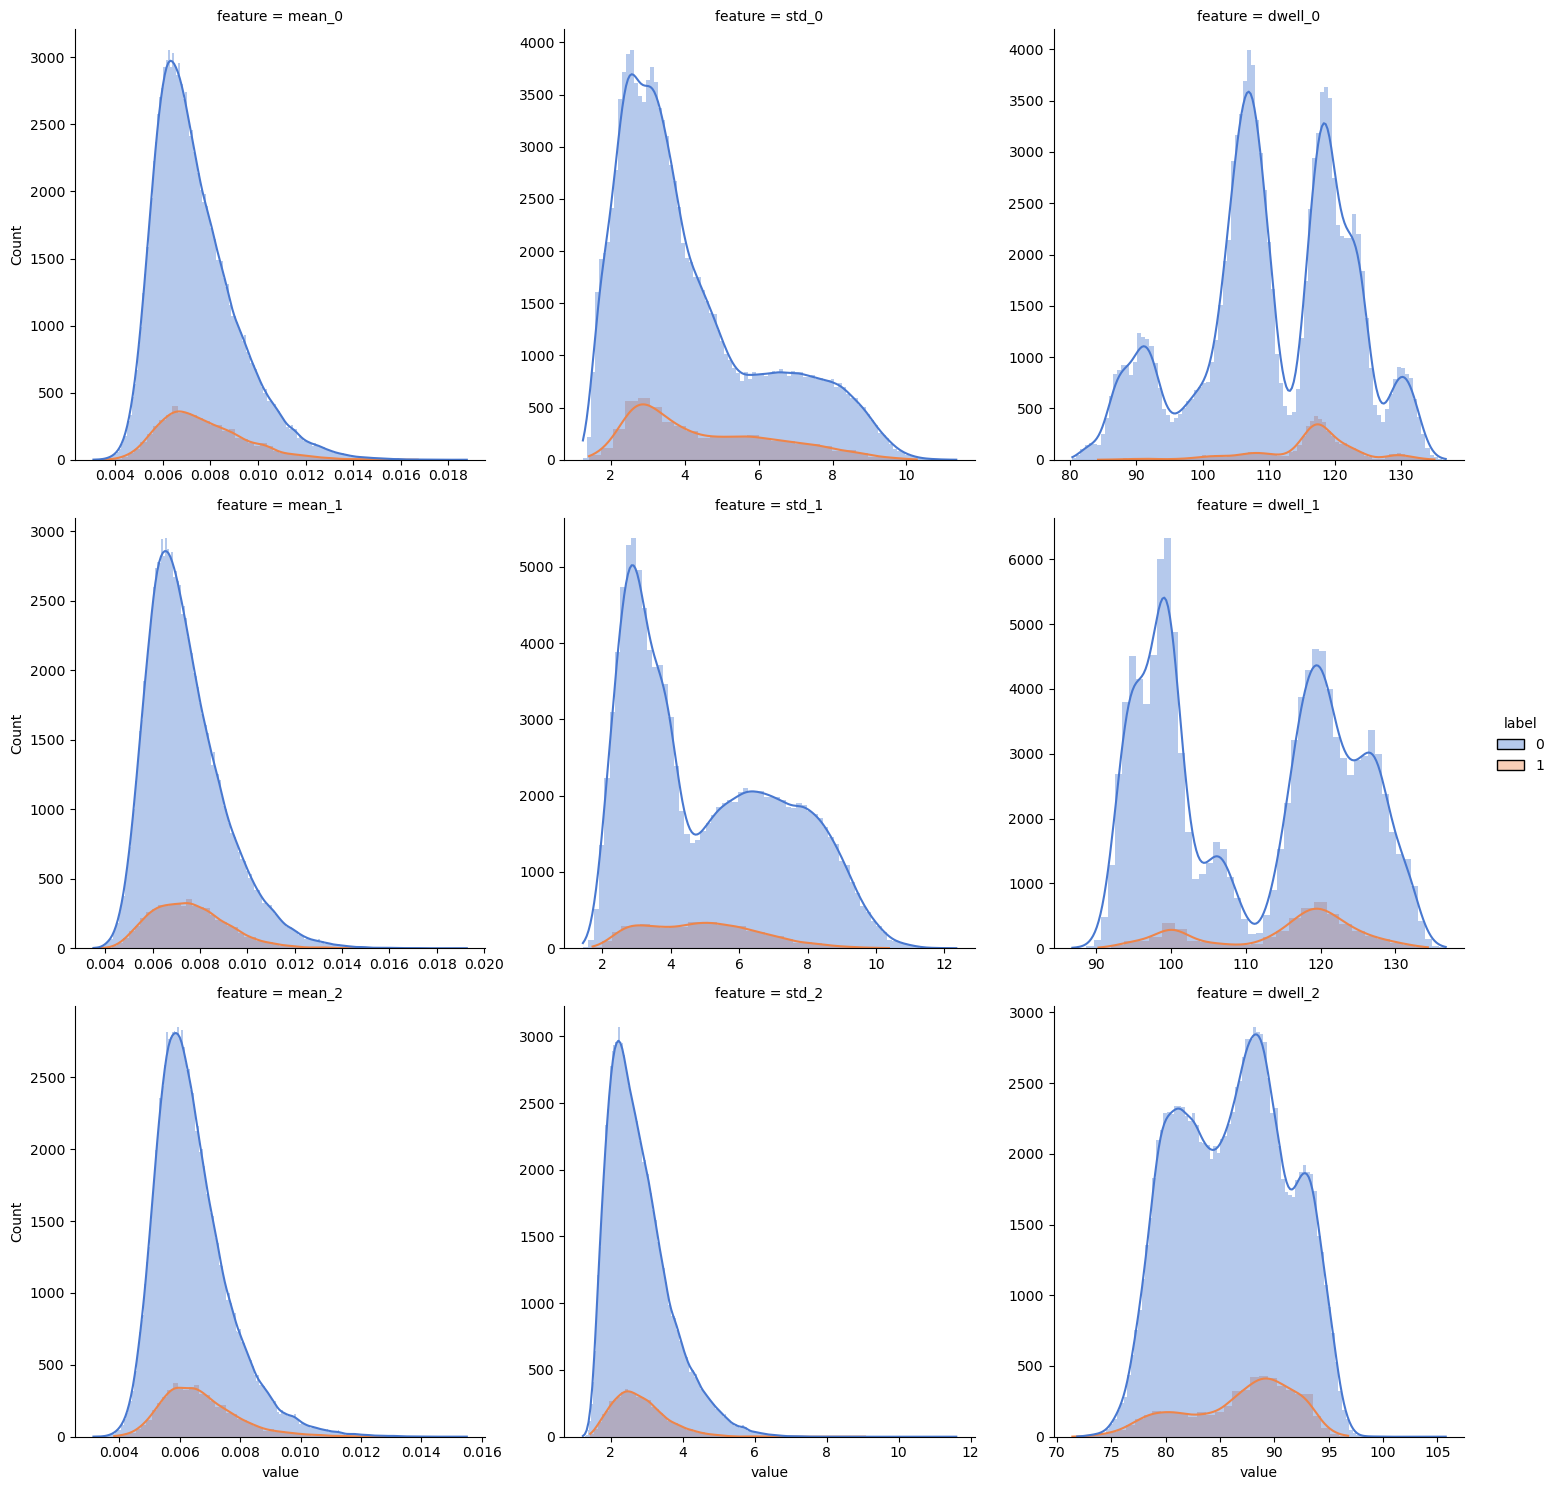

In [27]:
g = sns.displot(
    data=raw_df_p,
    x='value',
    hue='label',
    col='feature',
    col_wrap=3, 
    kind='hist',
    palette='muted',
    kde=True,
    alpha=0.4, 
    facet_kws=dict(sharex=False, sharey=False),
    common_bins = False
)

plt.show()

## b. Data Transformation

### Removing Skewness for numerical features

In [28]:
# Check for columns with zero
zero_cols = raw_df[features].loc[:, (raw_df == 0).any()].select_dtypes(include=['number']).columns
print(f'Features with zero values: {zero_cols}') # no columns with zero values

# Check skewness for numerical features
feat_skewness = raw_df[features].skew().sort_values(ascending=False) 
skewed_feats = feat_skewness[abs(feat_skewness) >= 0.4]
print('\n Initial Skewness: ')
display(skewed_feats)


skewed_cols = skewed_feats.index

ns_cols = []

test_skew_df = raw_df.copy()

for col in skewed_cols:
    log_col = "log_" + col
    ns_cols.append(log_col)

    # Perform log transformation
    test_skew_df[log_col] = np.log(test_skew_df[col])

    # Perform box-cox transformation
    bc_col = "bc_" + col
    ns_cols.append(bc_col)
    
    test_skew_df[bc_col], _ = stats.boxcox(test_skew_df[col])

print('\n Removed Skewness: ')
check_skewness = test_skew_df[ns_cols].skew()
check_skewness

Features with zero values: Index([], dtype='object')

 Initial Skewness: 


mean_2    1.175130
std_2     1.119404
mean_0    1.025139
mean_1    0.989190
std_0     0.940612
std_1     0.488076
dtype: float64


 Removed Skewness: 


log_mean_2    0.516434
bc_mean_2    -0.001905
log_std_2     0.359516
bc_std_2      0.026287
log_mean_0    0.386745
bc_mean_0     0.011277
log_mean_1    0.354969
bc_mean_1     0.007863
log_std_0     0.233265
bc_std_0      0.032245
log_std_1    -0.012769
bc_std_1     -0.003336
dtype: float64

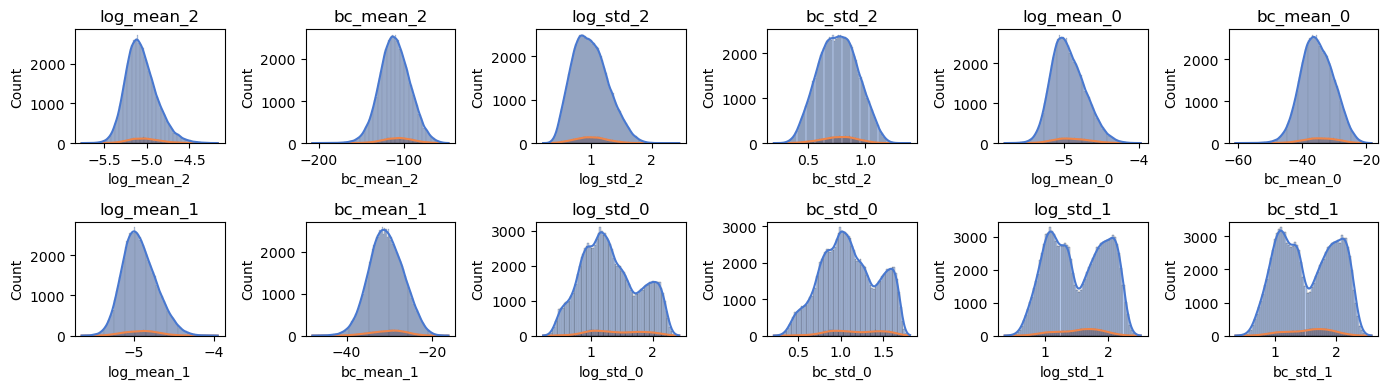

,transcript_id,transcript_position,sequence,mean_0,std_0,dwell_0,mean_1,std_1,dwell_1,mean_2,std_2,dwell_2,gene_id,label,log_mean_2,log_std_2,log_mean_0,log_mean_1,log_std_0,log_std_1
0,ENST00000000233,244,AAGACCA,0.007557,3.745030,124.818713,0.008973,7.382162,126.104396,0.006954,4.110575,80.563128,ENSG00000004059,0,-4.968489,1.413563,-4.885308,-4.713512,1.320430,1.999067
1,ENST00000000233,261,CAAACTG,0.005918,2.982139,109.863905,0.006298,3.049539,108.222892,0.007105,2.764846,94.059880,ENSG00000004059,0,-4.946999,1.016985,-5.129746,-5.067574,1.092641,1.114991
2,ENST00000000233,316,GAAACAG,0.007050,2.723636,105.515924,0.006769,3.754943,99.555952,0.006740,1.988157,89.271508,ENSG00000004059,0,-4.999738,0.687208,-4.954768,-4.995469,1.001968,1.323073
3,ENST00000000233,332,AGAACAT,0.009852,6.400859,129.684211,0.008038,2.644920,97.700510,0.005334,2.164892,89.154000,ENSG00000004059,0,-5.233644,0.772371,-4.620099,-4.823598,1.856432,0.972641
4,ENST00000000233,368,AGGACAA,0.009862,6.322094,117.767196,0.010885,5.831574,122.020833,0.009170,4.125759,85.253061,ENSG00000004059,0,-4.691801,1.417250,-4.619036,-4.520391,1.844051,1.763287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121833,ENST00000641834,1348,GGGACAT,0.008956,3.256583,118.084507,0.006618,4.795775,116.585714,0.005334,3.632647,81.725352,ENSG00000167747,1,-5.233648,1.289962,-4.715472,-5.017940,1.180679,1.567735
121834,ENST00000641834,1429,CTGACAC,0.007443,3.845574,111.619048,0.010305,9.105797,115.253731,0.004879,3.526515,80.156061,ENSG00000167747,0,-5.322802,1.260310,-4.900471,-4.575105,1.346923,2.208911
121835,ENST00000641834,1531,TGGACAC,0.006810,3.918438,113.711864,0.006169,4.498525,114.087719,0.005574,1.927759,84.501667,ENSG00000167747,1,-5.189672,0.656358,-4.989388,-5.088216,1.365693,1.503749
121836,ENST00000641834,1537,CTGACCA,0.006560,3.096786,109.818182,0.006951,6.552982,123.254545,0.006200,2.328868,82.289474,ENSG00000167747,0,-5.083177,0.845382,-5.026707,-4.968857,1.130365,1.879920


In [29]:
fig, axes = plt.subplots(2, 6, figsize=(14, 4))
axes = axes.flatten()

for i, feature in enumerate(ns_cols):
    sns.histplot(data=test_skew_df, x=feature, hue='label',
                ax=axes[i], palette='muted',
                 kde=True, alpha=0.4
    )
    axes[i].set_title(feature)

# Remove individual legends
for ax in axes:
    ax.legend_.remove() if ax.get_legend() else None

# # Add one shared legend (from the first plot)
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, title="Label", loc='upper right', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Box-cox transformation results in large values, to drop box-cox transformation
bc_cols = [
    'bc_mean_0',
    'bc_mean_1',
    'bc_mean_2',
    'bc_std_0',
    'bc_std_1',
    'bc_std_2'
]

no_skew_df = test_skew_df.copy().drop(columns=bc_cols)
no_skew_df

In [ ]:
# save one version for the reduced skew cols
drop_cols = [
    'mean_0',
    'mean_1',
    'mean_2',
    'std_0',
    'std_1',
    'std_2'
]

test_2_df = no_skew_df.drop(columns=drop_cols)
# test_2_df.to_csv('../data/int/f2_reduce_skew.csv', index=False) # save as intermediate df

### One-hot encoding for 'sequence'

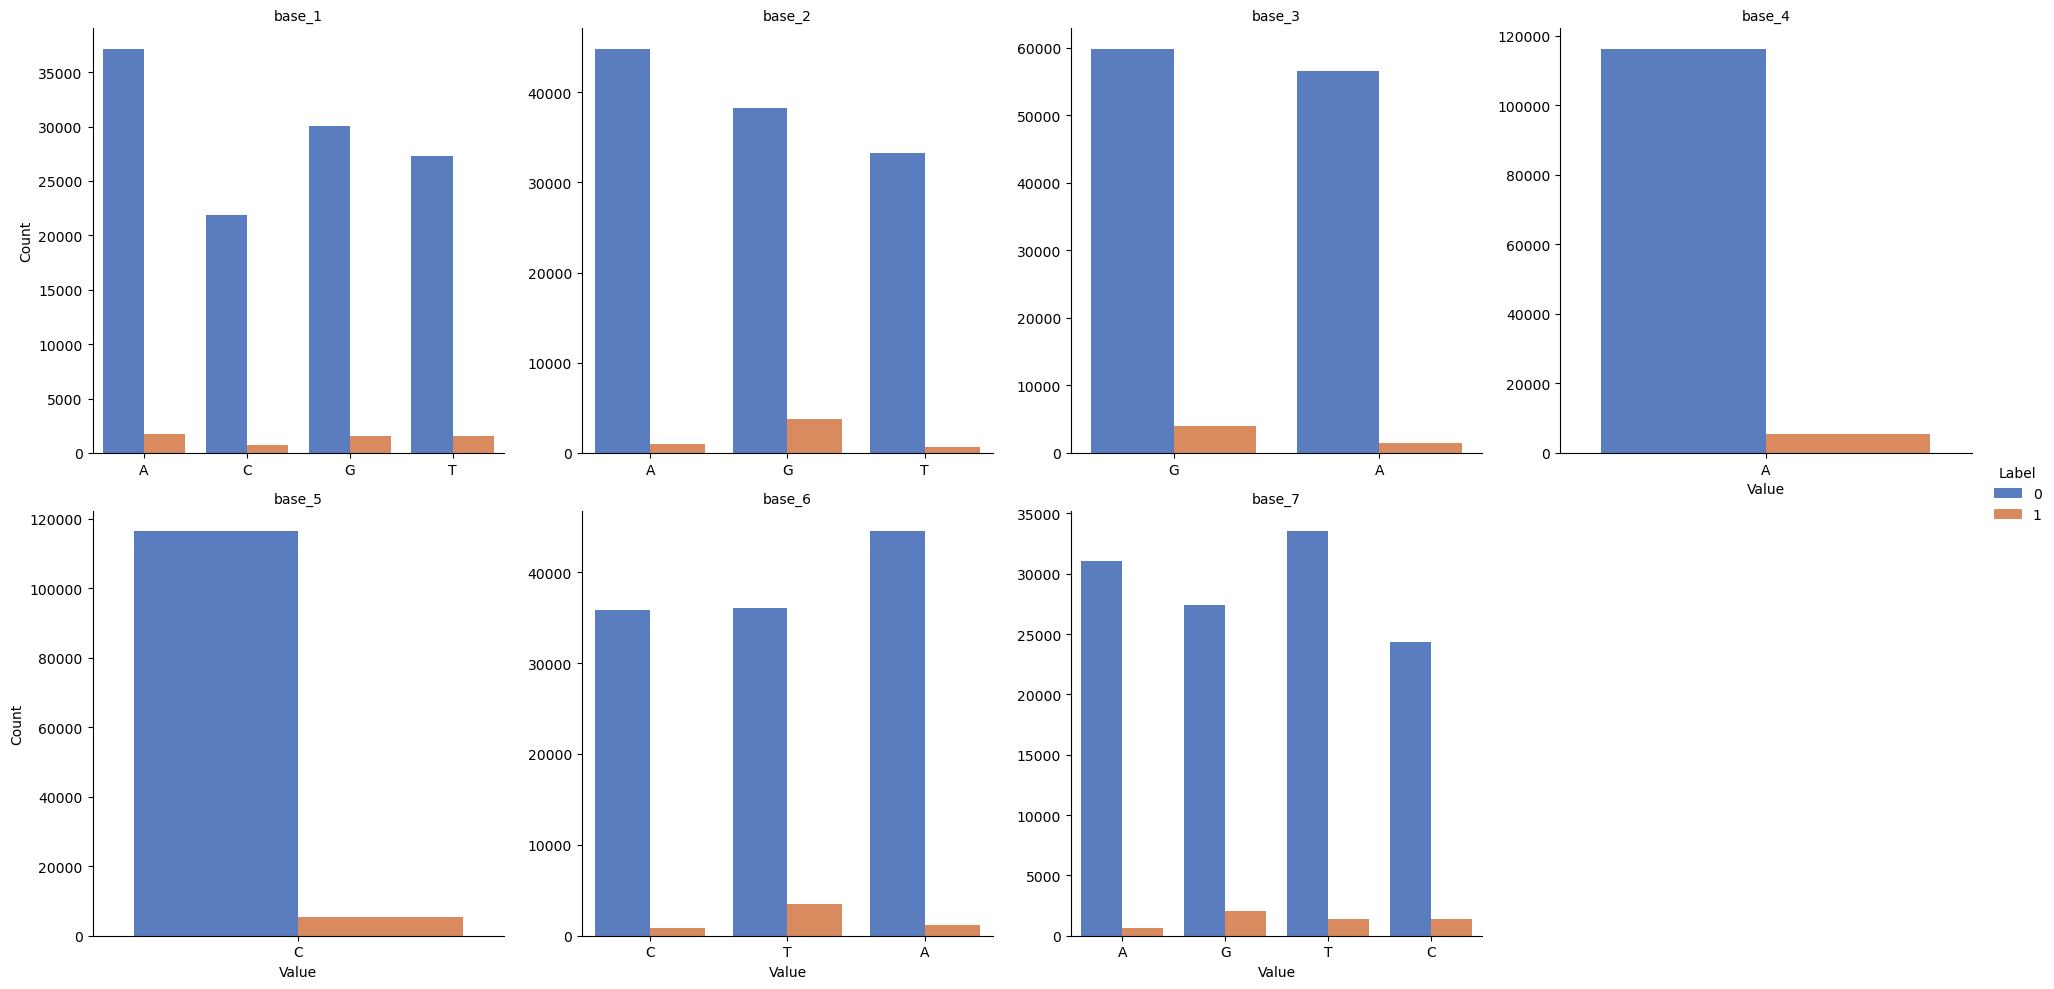

In [43]:
examine_seq_df = test_2_df.copy()

seq_list = examine_seq_df['sequence'].apply(lambda x: list(x))
seq_expanded = pd.DataFrame(seq_list.tolist(), columns=[f"base_{i+1}" for i in range(seq_list.str.len().max())])
base_cols = seq_expanded.columns.to_list()

examine_seq_df = examine_seq_df.join(seq_expanded)
    
examine_seq_df_p = examine_seq_df.melt(
    id_vars='label', 
    value_vars=base_cols, 
    var_name='feature', 
    value_name='value'
)

# Create the catplot
g = sns.catplot(
    data=examine_seq_df_p,
    x='value',
    hue='label',
    col='feature',
    col_wrap=4,   
    kind='count',
    palette='muted',
    sharey=False, sharex=False
)

# Adjust the plot
g.set_titles("{col_name}") 
g.set_axis_labels("Value", "Count")  
g._legend.set_title("Label") 

plt.show()

In [44]:
# 18 additional columns after one hot encoding
seq_encode_df = pd.get_dummies(examine_seq_df, columns=base_cols, dtype=int)

# drop base_4 and base_5 since there's only one possible value
seq_encode_df.drop(columns=['base_4_A', 'base_5_C', 'sequence'])

,transcript_id,transcript_position,dwell_0,dwell_1,dwell_2,gene_id,label,log_mean_2,log_std_2,log_mean_0,...,base_2_T,base_3_A,base_3_G,base_6_A,base_6_C,base_6_T,base_7_A,base_7_C,base_7_G,base_7_T
0,ENST00000000233,244,124.818713,126.104396,80.563128,ENSG00000004059,0,-4.968489,1.413563,-4.885308,...,0,0,1,0,1,0,1,0,0,0
1,ENST00000000233,261,109.863905,108.222892,94.059880,ENSG00000004059,0,-4.946999,1.016985,-5.129746,...,0,1,0,0,0,1,0,0,1,0
2,ENST00000000233,316,105.515924,99.555952,89.271508,ENSG00000004059,0,-4.999738,0.687208,-4.954768,...,0,1,0,1,0,0,0,0,1,0
3,ENST00000000233,332,129.684211,97.700510,89.154000,ENSG00000004059,0,-5.233644,0.772371,-4.620099,...,0,1,0,1,0,0,0,0,0,1
4,ENST00000000233,368,117.767196,122.020833,85.253061,ENSG00000004059,0,-4.691801,1.417250,-4.619036,...,0,0,1,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121833,ENST00000641834,1348,118.084507,116.585714,81.725352,ENSG00000167747,1,-5.233648,1.289962,-4.715472,...,0,0,1,1,0,0,0,0,0,1
121834,ENST00000641834,1429,111.619048,115.253731,80.156061,ENSG00000167747,0,-5.322802,1.260310,-4.900471,...,1,0,1,1,0,0,0,1,0,0
121835,ENST00000641834,1531,113.711864,114.087719,84.501667,ENSG00000167747,1,-5.189672,0.656358,-4.989388,...,0,0,1,1,0,0,0,1,0,0
121836,ENST00000641834,1537,109.818182,123.254545,82.289474,ENSG00000167747,0,-5.083177,0.845382,-5.026707,...,1,0,1,0,1,0,1,0,0,0


### 2nd Checkpoint
* Prepare 2nd feature set

In [45]:
seq_encode_df = seq_encode_df[[
    'transcript_id',
    'transcript_position',
    'gene_id',
    'dwell_0',
    'dwell_1',
    'dwell_2',
    'log_mean_0',
    'log_mean_1',
    'log_mean_2',
    'log_std_0',
    'log_std_1',
    'log_std_2',
    'base_1_A','base_1_C', 'base_1_G', 'base_1_T', 
    'base_2_A', 'base_2_G', 'base_2_T',
    'base_3_A', 'base_3_G', 
    'base_6_A', 'base_6_C', 'base_6_T', 
    'base_7_A', 'base_7_C', 'base_7_G', 'base_7_T',
    'label'
]]

print(examine_seq_df.shape)
print(examine_seq_df.columns)
print(seq_encode_df.shape)
print(seq_encode_df.columns)

# save as feature set 2
display(seq_encode_df)

# seq_encode_df.to_csv('../data/f2_noskew_ohe.csv', index=False)

(121838, 21)
Index(['transcript_id', 'transcript_position', 'sequence', 'dwell_0',
       'dwell_1', 'dwell_2', 'gene_id', 'label', 'log_mean_2', 'log_std_2',
       'log_mean_0', 'log_mean_1', 'log_std_0', 'log_std_1', 'base_1',
       'base_2', 'base_3', 'base_4', 'base_5', 'base_6', 'base_7'],
      dtype='object')
(121838, 29)
Index(['transcript_id', 'transcript_position', 'gene_id', 'dwell_0', 'dwell_1',
       'dwell_2', 'log_mean_0', 'log_mean_1', 'log_mean_2', 'log_std_0',
       'log_std_1', 'log_std_2', 'base_1_A', 'base_1_C', 'base_1_G',
       'base_1_T', 'base_2_A', 'base_2_G', 'base_2_T', 'base_3_A', 'base_3_G',
       'base_6_A', 'base_6_C', 'base_6_T', 'base_7_A', 'base_7_C', 'base_7_G',
       'base_7_T', 'label'],
      dtype='object')


,transcript_id,transcript_position,gene_id,dwell_0,dwell_1,dwell_2,log_mean_0,log_mean_1,log_mean_2,log_std_0,...,base_3_A,base_3_G,base_6_A,base_6_C,base_6_T,base_7_A,base_7_C,base_7_G,base_7_T,label
0,ENST00000000233,244,ENSG00000004059,124.818713,126.104396,80.563128,-4.885308,-4.713512,-4.968489,1.320430,...,0,1,0,1,0,1,0,0,0,0
1,ENST00000000233,261,ENSG00000004059,109.863905,108.222892,94.059880,-5.129746,-5.067574,-4.946999,1.092641,...,1,0,0,0,1,0,0,1,0,0
2,ENST00000000233,316,ENSG00000004059,105.515924,99.555952,89.271508,-4.954768,-4.995469,-4.999738,1.001968,...,1,0,1,0,0,0,0,1,0,0
3,ENST00000000233,332,ENSG00000004059,129.684211,97.700510,89.154000,-4.620099,-4.823598,-5.233644,1.856432,...,1,0,1,0,0,0,0,0,1,0
4,ENST00000000233,368,ENSG00000004059,117.767196,122.020833,85.253061,-4.619036,-4.520391,-4.691801,1.844051,...,0,1,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121833,ENST00000641834,1348,ENSG00000167747,118.084507,116.585714,81.725352,-4.715472,-5.017940,-5.233648,1.180679,...,0,1,1,0,0,0,0,0,1,1
121834,ENST00000641834,1429,ENSG00000167747,111.619048,115.253731,80.156061,-4.900471,-4.575105,-5.322802,1.346923,...,0,1,1,0,0,0,1,0,0,0
121835,ENST00000641834,1531,ENSG00000167747,113.711864,114.087719,84.501667,-4.989388,-5.088216,-5.189672,1.365693,...,0,1,1,0,0,0,1,0,0,1
121836,ENST00000641834,1537,ENSG00000167747,109.818182,123.254545,82.289474,-5.026707,-4.968857,-5.083177,1.130365,...,0,1,0,1,0,1,0,0,0,0


### PCA Plot
* Check separation after some feature engineering

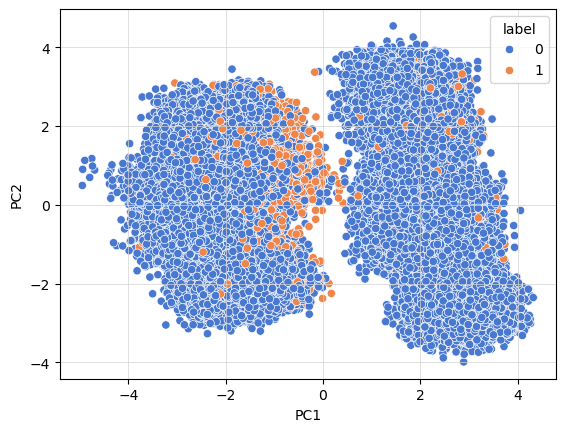

In [47]:
X = seq_encode_df.drop(columns=['transcript_id', 'transcript_position','gene_id', 'label'])
y = seq_encode_df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['label'] = y


sns.scatterplot(pca_df, x='PC1', y='PC2', hue='label', palette='muted')
plt.grid(color='lightgray', linewidth=0.5)
plt.show()

### Check Correlation

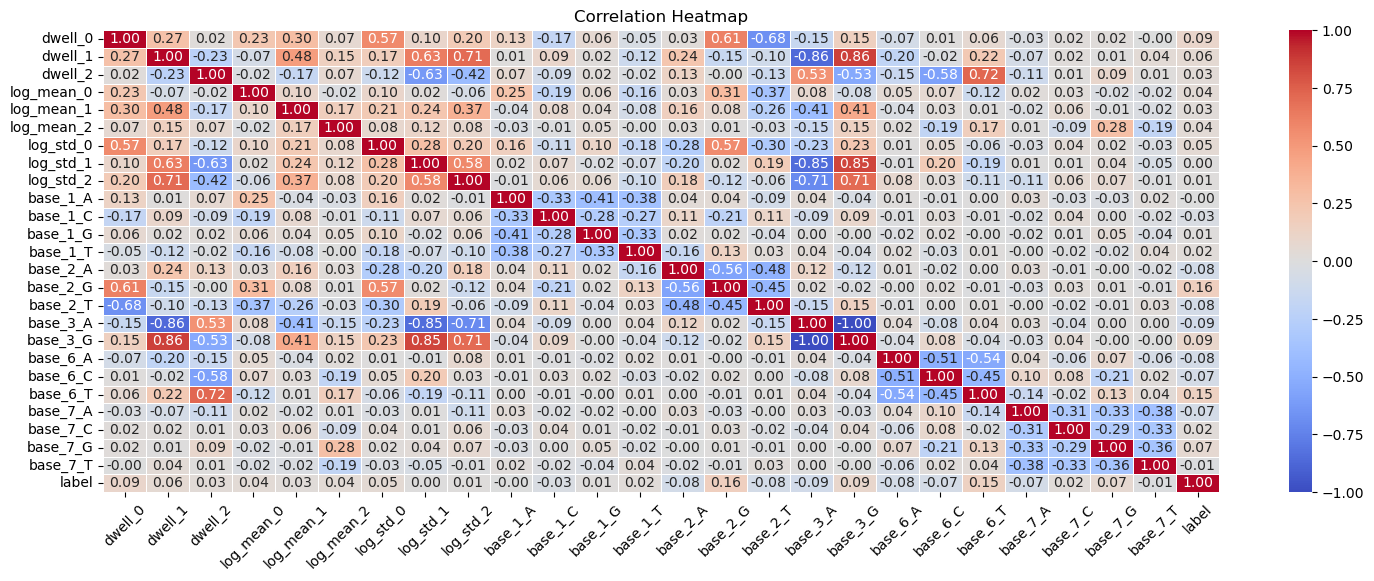

In [74]:
corr_ft_df = seq_encode_df.drop(columns=['transcript_position', 'transcript_id',  'gene_id'])

corr_ft = corr_ft_df.corr(method='spearman')
corr_ft['label'].sort_values(ascending=False)

plt.figure(figsize=(18, 6))
sns.heatmap(corr_ft, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.xticks(rotation=45)
plt.show()

## 3. Create New Features

In [61]:
# Add back the original features (mean and std)
add_cols = no_skew_df[[
    'mean_0',
    'std_0',
    'mean_1',
    'std_1',
    'mean_2',
    'std_2',
    'sequence'
]]

new_feat_df = seq_encode_df.copy()
new_feat_df = pd.concat([new_feat_df, add_cols], axis=1)
new_feat_df

,transcript_id,transcript_position,gene_id,dwell_0,dwell_1,dwell_2,log_mean_0,log_mean_1,log_mean_2,log_std_0,...,base_7_G,base_7_T,label,mean_0,std_0,mean_1,std_1,mean_2,std_2,sequence
0,ENST00000000233,244,ENSG00000004059,124.818713,126.104396,80.563128,-4.885308,-4.713512,-4.968489,1.320430,...,0,0,0,0.007557,3.745030,0.008973,7.382162,0.006954,4.110575,AAGACCA
1,ENST00000000233,261,ENSG00000004059,109.863905,108.222892,94.059880,-5.129746,-5.067574,-4.946999,1.092641,...,1,0,0,0.005918,2.982139,0.006298,3.049539,0.007105,2.764846,CAAACTG
2,ENST00000000233,316,ENSG00000004059,105.515924,99.555952,89.271508,-4.954768,-4.995469,-4.999738,1.001968,...,1,0,0,0.007050,2.723636,0.006769,3.754943,0.006740,1.988157,GAAACAG
3,ENST00000000233,332,ENSG00000004059,129.684211,97.700510,89.154000,-4.620099,-4.823598,-5.233644,1.856432,...,0,1,0,0.009852,6.400859,0.008038,2.644920,0.005334,2.164892,AGAACAT
4,ENST00000000233,368,ENSG00000004059,117.767196,122.020833,85.253061,-4.619036,-4.520391,-4.691801,1.844051,...,0,0,0,0.009862,6.322094,0.010885,5.831574,0.009170,4.125759,AGGACAA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121833,ENST00000641834,1348,ENSG00000167747,118.084507,116.585714,81.725352,-4.715472,-5.017940,-5.233648,1.180679,...,0,1,1,0.008956,3.256583,0.006618,4.795775,0.005334,3.632647,GGGACAT
121834,ENST00000641834,1429,ENSG00000167747,111.619048,115.253731,80.156061,-4.900471,-4.575105,-5.322802,1.346923,...,0,0,0,0.007443,3.845574,0.010305,9.105797,0.004879,3.526515,CTGACAC
121835,ENST00000641834,1531,ENSG00000167747,113.711864,114.087719,84.501667,-4.989388,-5.088216,-5.189672,1.365693,...,0,0,1,0.006810,3.918438,0.006169,4.498525,0.005574,1.927759,TGGACAC
121836,ENST00000641834,1537,ENSG00000167747,109.818182,123.254545,82.289474,-5.026707,-4.968857,-5.083177,1.130365,...,0,0,0,0.006560,3.096786,0.006951,6.552982,0.006200,2.328868,CTGACCA


In [62]:
# Explore new features

# # Find coefficient of variation (variability)
new_feat_df['cv_0'] = new_feat_df['std_0'] / new_feat_df['mean_0']
new_feat_df['cv_1'] = new_feat_df['std_1'] / new_feat_df['mean_1']
new_feat_df['cv_2'] = new_feat_df['std_2'] / new_feat_df['mean_2']


# Find the mean across 3 positions
new_feat_df['all_mean'] = new_feat_df[['mean_0', 'mean_1', 'mean_2']].mean(axis=1)
new_feat_df['all_std'] = new_feat_df[['std_0', 'std_1', 'std_2']].mean(axis=1)
new_feat_df['all_dwell'] = new_feat_df[['dwell_0', 'dwell_1', 'dwell_2']].mean(axis=1)

new_feat_df.head(5)

,transcript_id,transcript_position,gene_id,dwell_0,dwell_1,dwell_2,log_mean_0,log_mean_1,log_mean_2,log_std_0,...,std_1,mean_2,std_2,sequence,cv_0,cv_1,cv_2,all_mean,all_std,all_dwell
0,ENST00000000233,244,ENSG00000004059,124.818713,126.104396,80.563128,-4.885308,-4.713512,-4.968489,1.320430,...,7.382162,0.006954,4.110575,AAGACCA,495.584249,822.689623,591.139551,0.007828,5.079256,110.495413
1,ENST00000000233,261,ENSG00000004059,109.863905,108.222892,94.059880,-5.129746,-5.067574,-4.946999,1.092641,...,3.049539,0.007105,2.764846,CAAACTG,503.904539,484.231967,389.157540,0.006440,2.932175,104.048892
2,ENST00000000233,316,ENSG00000004059,105.515924,99.555952,89.271508,-4.954768,-4.995469,-4.999738,1.001968,...,3.754943,0.006740,1.988157,GAAACAG,386.346793,554.763417,294.991405,0.006853,2.822245,98.114461
3,ENST00000000233,332,ENSG00000004059,129.684211,97.700510,89.154000,-4.620099,-4.823598,-5.233644,1.856432,...,2.644920,0.005334,2.164892,AGAACAT,649.713118,329.059652,405.862461,0.007741,3.736890,105.512907
4,ENST00000000233,368,ENSG00000004059,117.767196,122.020833,85.253061,-4.619036,-4.520391,-4.691801,1.844051,...,5.831574,0.009170,4.125759,AGGACAA,641.036258,535.755611,449.911423,0.009972,5.426476,108.347030


In [63]:
# Pivot for viz
new_feat = [
    'cv_0',
    'cv_1',
    'cv_2',
    'all_mean',
    'all_std',
    'all_dwell'
]


new_feat_df_p = new_feat_df.melt(
    id_vars='label',
    value_vars=new_feat,
    var_name='new_feature',
    value_name='value'
)

new_feat_df_p

,label,new_feature,value
0,0,cv_0,495.584249
1,0,cv_0,503.904539
2,0,cv_0,386.346793
3,0,cv_0,649.713118
4,0,cv_0,641.036258
...,...,...,...
731023,1,all_dwell,105.465191
731024,0,all_dwell,102.342947
731025,1,all_dwell,104.100417
731026,0,all_dwell,105.120734


### Boxplots for new features

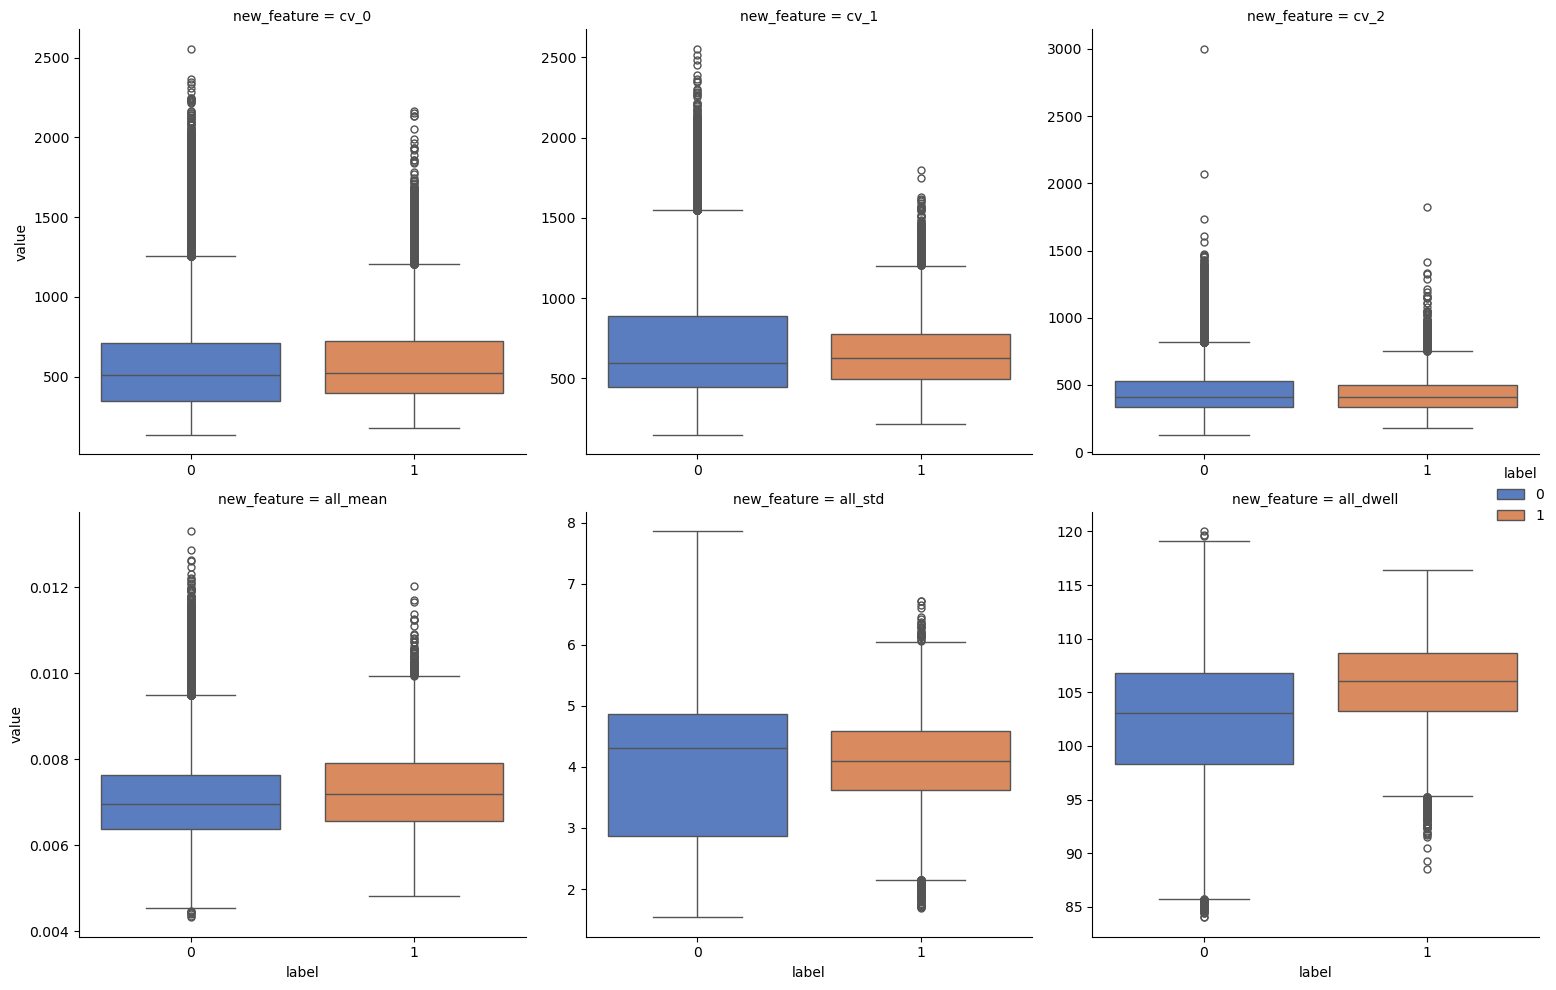

In [64]:
g = sns.catplot(
    data=new_feat_df_p,
    x='label',
    y='value',
    hue='label',
    col='new_feature',
    col_wrap=3,       
    kind='box',
    palette='muted',
    sharex=False, sharey=False
)


plt.tight_layout()
plt.show()

### Histograms for new features

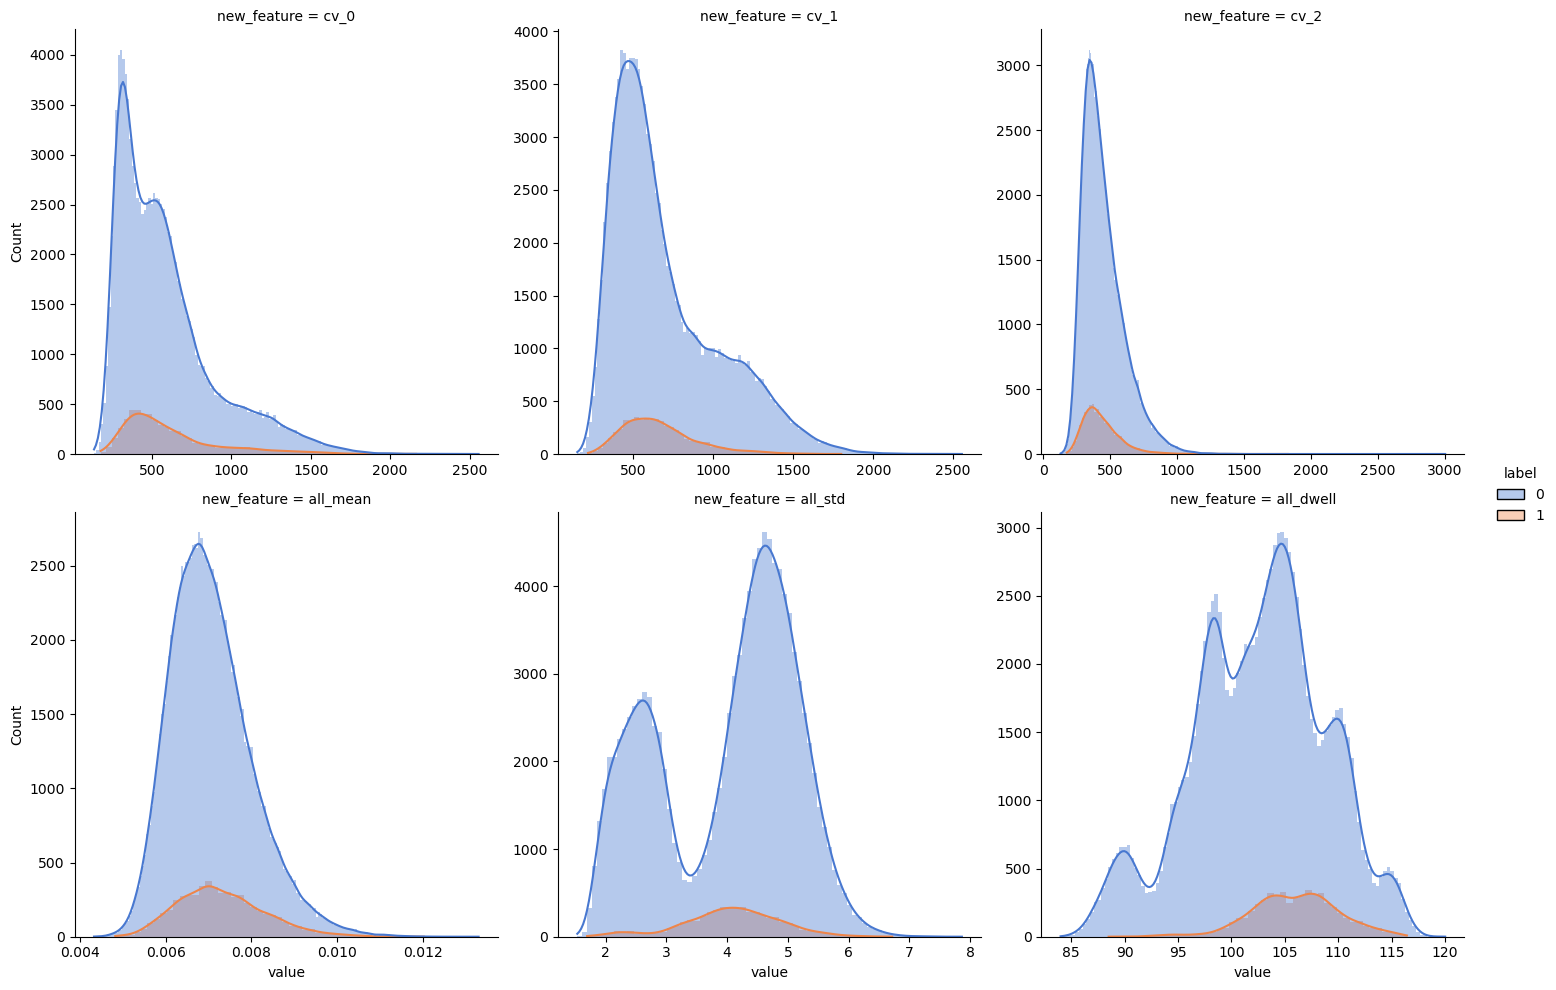

In [65]:
g = sns.displot(
    data=new_feat_df_p,
    x='value',
    hue='label',
    col='new_feature',
    col_wrap=3, 
    kind='hist',
    palette='muted',
    kde=True,
    alpha=0.4, 
    facet_kws=dict(sharex=False, sharey=False),
    common_bins = False
)

plt.show()

### Check Skewness

In [66]:
# Check for columns with zero
zero_cols = new_feat_df[new_feat].loc[:, (new_feat_df == 0).any()].select_dtypes(include=['number']).columns
print(f'Features with zero values: {zero_cols}') # no columns with zero values

# Check skewness for numerical features
feat_skewness = new_feat_df[new_feat].skew().sort_values(ascending=False) 
display(feat_skewness)
skewed_feats = feat_skewness[abs(feat_skewness) >= 1]
print('\n Initial Skewness: ')
display(skewed_feats)


skewed_cols = skewed_feats.index

ns_cols = []

for col in skewed_cols:
    log_col = "log_" + col
    ns_cols.append(log_col)

    # Perform log transformation
    new_feat_df[log_col] = np.log(new_feat_df[col])
    new_feat_df.drop(columns=col, inplace=True)

print('\n Removed Skewness: ')
check_skewness = new_feat_df[ns_cols].skew()
check_skewness

Features with zero values: Index([], dtype='object')


cv_0         1.366156
cv_2         1.247936
cv_1         1.069357
all_mean     0.730552
all_dwell   -0.268065
all_std     -0.344773
dtype: float64


 Initial Skewness: 


cv_0    1.366156
cv_2    1.247936
cv_1    1.069357
dtype: float64


 Removed Skewness: 


log_cv_0    0.317525
log_cv_2    0.277743
log_cv_1    0.229962
dtype: float64

### 3rd Checkpoint
* Include new features (31 features, 4 info columns)

In [87]:
new_feat_df.head(5)

,transcript_id,transcript_position,gene_id,dwell_0,dwell_1,dwell_2,log_mean_0,log_mean_1,log_mean_2,log_std_0,...,std_1,mean_2,std_2,sequence,all_mean,all_std,all_dwell,log_cv_0,log_cv_2,log_cv_1
0,ENST00000000233,244,ENSG00000004059,124.818713,126.104396,80.563128,-4.885308,-4.713512,-4.968489,1.320430,...,7.382162,0.006954,4.110575,AAGACCA,0.007828,5.079256,110.495413,6.205737,6.382052,6.712579
1,ENST00000000233,261,ENSG00000004059,109.863905,108.222892,94.059880,-5.129746,-5.067574,-4.946999,1.092641,...,3.049539,0.007105,2.764846,CAAACTG,0.006440,2.932175,104.048892,6.222387,5.963984,6.182564
2,ENST00000000233,316,ENSG00000004059,105.515924,99.555952,89.271508,-4.954768,-4.995469,-4.999738,1.001968,...,3.754943,0.006740,1.988157,GAAACAG,0.006853,2.822245,98.114461,5.956735,5.686946,6.318542
3,ENST00000000233,332,ENSG00000004059,129.684211,97.700510,89.154000,-4.620099,-4.823598,-5.233644,1.856432,...,2.644920,0.005334,2.164892,AGAACAT,0.007741,3.736890,105.512907,6.476531,6.006014,5.796239
4,ENST00000000233,368,ENSG00000004059,117.767196,122.020833,85.253061,-4.619036,-4.520391,-4.691801,1.844051,...,5.831574,0.009170,4.125759,AGGACAA,0.009972,5.426476,108.347030,6.463086,6.109051,6.283678


In [68]:
test_3_df = new_feat_df.copy()
test_3_df = test_3_df.drop(columns=add_cols)
test_3_df.head(5)

# test_3_df.to_csv('../data/f3_data/f3_transformed_new.csv', index=False)

,transcript_id,transcript_position,gene_id,dwell_0,dwell_1,dwell_2,log_mean_0,log_mean_1,log_mean_2,log_std_0,...,base_7_C,base_7_G,base_7_T,label,all_mean,all_std,all_dwell,log_cv_0,log_cv_2,log_cv_1
0,ENST00000000233,244,ENSG00000004059,124.818713,126.104396,80.563128,-4.885308,-4.713512,-4.968489,1.320430,...,0,0,0,0,0.007828,5.079256,110.495413,6.205737,6.382052,6.712579
1,ENST00000000233,261,ENSG00000004059,109.863905,108.222892,94.059880,-5.129746,-5.067574,-4.946999,1.092641,...,0,1,0,0,0.006440,2.932175,104.048892,6.222387,5.963984,6.182564
2,ENST00000000233,316,ENSG00000004059,105.515924,99.555952,89.271508,-4.954768,-4.995469,-4.999738,1.001968,...,0,1,0,0,0.006853,2.822245,98.114461,5.956735,5.686946,6.318542
3,ENST00000000233,332,ENSG00000004059,129.684211,97.700510,89.154000,-4.620099,-4.823598,-5.233644,1.856432,...,0,0,1,0,0.007741,3.736890,105.512907,6.476531,6.006014,5.796239
4,ENST00000000233,368,ENSG00000004059,117.767196,122.020833,85.253061,-4.619036,-4.520391,-4.691801,1.844051,...,0,0,0,0,0.009972,5.426476,108.347030,6.463086,6.109051,6.283678


### Check Correlation

In [ ]:
corr_new = test_3_df.drop(columns=[
    'transcript_id', 'transcript_position', 'gene_id'
]).corr(method='spearman')
corr_new['label'].sort_values(ascending=False)

label         1.000000
base_2_G      0.157215
base_6_T      0.145931
all_dwell     0.119912
dwell_0       0.094298
base_3_G      0.089932
base_7_G      0.065190
dwell_1       0.059398
all_mean      0.049251
log_std_0     0.046897
log_mean_2    0.043421
log_mean_0    0.040003
dwell_2       0.031339
log_cv_0      0.027347
log_mean_1    0.026279
base_1_T      0.024010
base_7_C      0.023865
log_std_2     0.014080
base_1_G      0.009311
log_cv_1      0.006163
log_std_1     0.002982
base_1_A     -0.004549
all_std      -0.011771
log_cv_2     -0.013555
base_7_T     -0.013605
base_1_C     -0.031327
base_6_C     -0.069726
base_7_A     -0.071818
base_6_A     -0.075156
base_2_T     -0.076168
base_2_A     -0.083826
base_3_A     -0.089932
Name: label, dtype: float64

## 4. Try 5-mer Encoding

In [79]:
# All possible 5-mers (4^5 = 1024)
bases = ['A', 'C', 'G', 'T']
all_5mers = [''.join(p) for p in itertools.product(bases, repeat=5)]

# Extract overlapping 5-mers
def get_kmers(seq, k=5):
    return [seq[i:i+k] for i in range(len(seq) - k + 1)]

# Convert one sequence into a frequency dictionary
def kmer_freq(seq, k=5):
    kmers = get_kmers(seq, k)
    counts = Counter(kmers)
    total = len(kmers)
    return {kmer: counts.get(kmer, 0) / total for kmer in all_5mers}

In [ ]:
seq_ohe_cols = ['base_1_A', 'base_1_C', 'base_1_G', 'base_1_T', 
                'base_2_A', 'base_2_G', 'base_2_T', 
                'base_3_A', 'base_3_G',
                'base_6_A', 'base_6_C', 'base_6_T', 
                'base_7_A', 'base_7_C', 'base_7_G', 'base_7_T', 'label']

freq_encode_df = test_3_df.copy()
label_df = freq_encode_df['label']
freq_encode_df.drop(columns=seq_ohe_cols, inplace=True)

# Apply encoding to each row
encoded_list = no_skew_df['sequence'].apply(lambda s: kmer_freq(s, k=5))

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded_list.tolist())

# Combine with original df
df_encoded = pd.concat([freq_encode_df, encoded_df, label_df], axis=1)

df_encoded.head(5)

,transcript_id,transcript_position,gene_id,dwell_0,dwell_1,dwell_2,log_mean_0,log_mean_1,log_mean_2,log_std_0,...,TTTCT,TTTGA,TTTGC,TTTGG,TTTGT,TTTTA,TTTTC,TTTTG,TTTTT,label
0,ENST00000000233,244,ENSG00000004059,124.818713,126.104396,80.563128,-4.885308,-4.713512,-4.968489,1.320430,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,ENST00000000233,261,ENSG00000004059,109.863905,108.222892,94.059880,-5.129746,-5.067574,-4.946999,1.092641,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,ENST00000000233,316,ENSG00000004059,105.515924,99.555952,89.271508,-4.954768,-4.995469,-4.999738,1.001968,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,ENST00000000233,332,ENSG00000004059,129.684211,97.700510,89.154000,-4.620099,-4.823598,-5.233644,1.856432,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,ENST00000000233,368,ENSG00000004059,117.767196,122.020833,85.253061,-4.619036,-4.520391,-4.691801,1.844051,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


### 4th Checkpoint
* Replace one hot encoding with 5-mer encoding

In [ ]:
# df_encoded.to_csv('../data/f3_data/f3_transformed_new_encoded.csv', index=False)